In [1]:
# !pip uninstall pybamm -y

In [2]:
# ! pip install -e.

In [3]:
# aktiviraj myenv okolje
import pybamm
import pybammeis 
import numpy as np
import matplotlib.pyplot as plt
import time
from ipywidgets import interact, FloatSlider
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [4]:
# Shrani slike
save_fig = False 

# Shrani animacijo
save_ani = False

# Formatiranje grafov
# Nastavitev velikosti grafa (širina, višina v inch-ih)
fig_size = figsize=(8, 6)  

# Nastavitev velikosti pisave
plt.rcParams.update({
    'font.size': 20,           # Osnovna velikost pisave
    'axes.titlesize': 20,      # Velikost naslova grafa
    'axes.labelsize': 20,      # Velikost pisave na osi
    'xtick.labelsize': 18,     # Velikost številk na x osi
    'ytick.labelsize': 18,     # Velikost številk na y osi
    'legend.fontsize': 18,     # Velikost pisave v legendi
})

## Nova koda

In [ ]:
def my_current(t):
    return pybamm.sin( 2*np.pi * t *10)/1e1 # amplitude 0.1 A, frequency 10 Hz

t_eval = np.linspace(0, 3, 1000)


In [71]:
# model, ki ima le mehansko degradacijo
model_DFN = pybamm.lithium_ion.BasicDFN()


param0 = pybamm.ParameterValues("Ai2020") 
param0.update(
    {"Hydrostatic stress [Pa]": 0},
    check_already_exists=False  
)
param0["Current function [A]"] = my_current

param1 = pybamm.ParameterValues("Ai2020") 
param1.update(
    {"Hydrostatic stress [Pa]": 1e9},
    check_already_exists=False  
)
param1["Current function [A]"] = my_current

param2 = pybamm.ParameterValues("Ai2020") 
param2.update(
    {"Hydrostatic stress [Pa]": 2e9},
    check_already_exists=False  
)
param2["Current function [A]"] = my_current

var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

# experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
solver = pybamm.IDAKLUSolver()  



sim_DFN_0 = pybamm.Simulation(model= model_DFN, parameter_values=param0, var_pts=var_pts, solver=solver, #experiment=experiment 
                              )
sim_DFN_1 = pybamm.Simulation(model= model_DFN, parameter_values=param1, var_pts=var_pts, solver=solver, #experiment=experiment 
                              )
sim_DFN_2 = pybamm.Simulation(model= model_DFN, parameter_values=param2, var_pts=var_pts, solver=solver,#experiment=experiment 
                              )

######################
# t_eval = [0, 3600]  
######################

start = time.time()
sol_DFN = sim_DFN_0.solve(t_eval=t_eval)
end = time.time()
print(f"Simulacija DFN_0 zaključena v {end - start:.2f} s.")

start = time.time()
sol_DFN_1 = sim_DFN_1.solve(t_eval=t_eval)
end = time.time()
print(f"Simulacija DFN_1 zaključena v {end - start:.2f} s.")

start = time.time()
sol_DFN_2 = sim_DFN_2.solve(t_eval=t_eval)
end = time.time()
print(f"Simulacija DFN_2 zaključena v {end - start:.2f} s.")

Simulacija DFN_0 zaključena v 12.65 s.
Simulacija DFN_1 zaključena v 11.36 s.
Simulacija DFN_2 zaključena v 11.80 s.


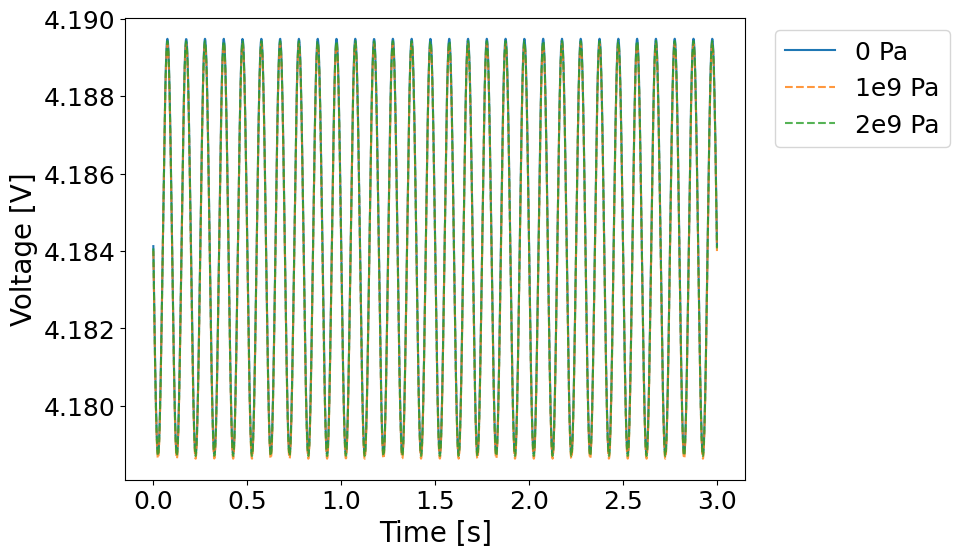

In [72]:
voltage = sol_DFN["Voltage [V]"].entries 
voltage_1 = sol_DFN_1["Voltage [V]"].entries
voltage_2 = sol_DFN_2["Voltage [V]"].entries
x = sol_DFN["Time [s]"].entries
x_1 = sol_DFN_1["Time [s]"].entries
x_2 = sol_DFN_2["Time [s]"].entries

plt.figure(figsize=fig_size)
plt.plot(x, voltage, label="0 Pa")
plt.plot(x_1, voltage_1+4.1845-4.1525, label="1e9 Pa", alpha=0.8, linestyle='--')
plt.plot(x_2, voltage_2+4.1845-4.1203, label="2e9 Pa", alpha=0.8, linestyle='--')
plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")
plt.legend(loc ='upper right', bbox_to_anchor=(1.35, 1))

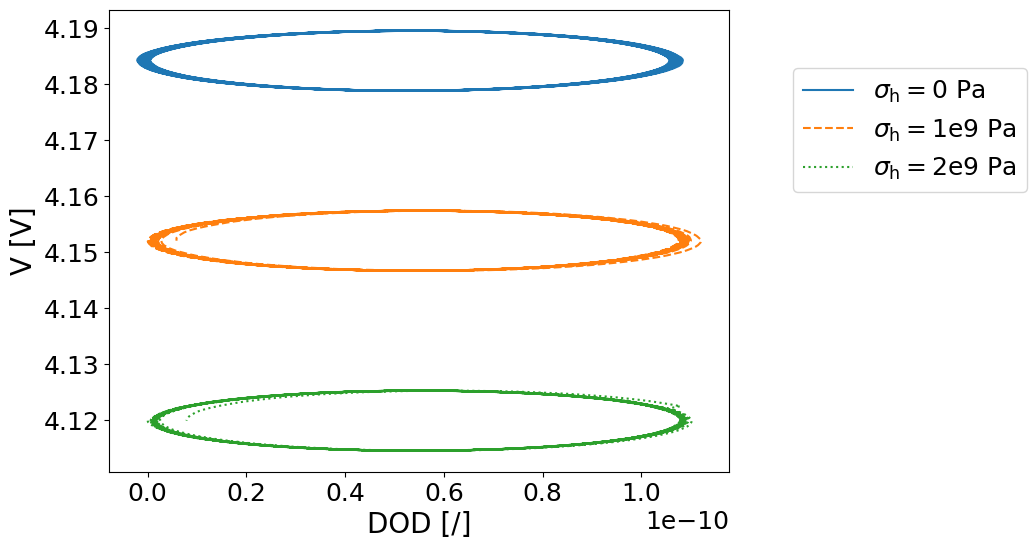

In [73]:
Q_discharged = sol_DFN["Discharge capacity [A.h]"].entries
# Q_max = Q_discharged[-1] 
Q_max = 2.28*3600
DOD = (Q_discharged / Q_max)

Q_discharged = sol_DFN_1["Discharge capacity [A.h]"].entries
# Q_max = Q_discharged[-1] 
Q_max = 2.28*3600
DOD_1 = (Q_discharged / Q_max)

Q_discharged = sol_DFN_2["Discharge capacity [A.h]"].entries
# Q_max = Q_discharged[-1] 
Q_max = 2.28*3600
DOD_2 = (Q_discharged / Q_max)

x_val = [DOD, 
         DOD_1,
        DOD_2
         ]
y_val = [sol_DFN["Voltage [V]"].data, 
         sol_DFN_1["Voltage [V]"].data,
        sol_DFN_2["Voltage [V]"].data
         ]

plt.figure(figsize=fig_size)
for i in range(len(x_val)):
    plt.plot(x_val[i], y_val[i], label=["$\sigma_{\mathrm{h}}=$0 Pa", 
                                        "$\sigma_{\mathrm{h}}=$1e9 Pa", 
                                        "$\sigma_{\mathrm{h}}=$2e9 Pa", 
                                        # "$\sigma_{\mathrm{h}}=$1e9 Pa" , 
                                        # "$\sigma_{\mathrm{h}}=$2e9 Pa", 
                                        # "$\sigma_{\mathrm{h}}=$4e9 Pa", 
                                        # "$\sigma_{\mathrm{h}}=$6e9 Pa",
                                        # "$\sigma_{\mathrm{h}}=$8e9 Pa", 
                                        # "$\sigma_{\mathrm{h}}=$1e10 Pa", 
                                        # # "$\sigma_{\mathrm{h}}=$1e11 Pa"
                                        ][i], 
                                        linestyle=["-", "--", ":", "-", "-", "-", "-", "-", "-", "-"][i])
    
# plt.xlim(3000, 3600)
# plt.ylim(3.5, 3.6)
plt.xlabel("DOD [/]")
plt.ylabel("V [V]")
plt.legend(loc="upper right", bbox_to_anchor=(1.5, 0.9))

if save_fig:
    plt.savefig("graphs/OCV_i0.eps", format='eps', dpi=600, bbox_inches='tight')


## Stara koda

In [86]:
# model, ki ima le mehansko degradacijo
model_DFN = pybamm.lithium_ion.BasicDFN()

param0 = pybamm.ParameterValues("Ai2020") 
param0.update(
    {"Hydrostatic stress [Pa]": 0},
    check_already_exists=False  
)


param1 = pybamm.ParameterValues("Ai2020") 
param1.update(
    {"Hydrostatic stress [Pa]": 1e9},
    check_already_exists=False  
)


param2 = pybamm.ParameterValues("Ai2020") 
param2.update(
    {"Hydrostatic stress [Pa]": 2e9},
    check_already_exists=False  
)


var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
solver = pybamm.IDAKLUSolver()  



sim_DFN_0 = pybamm.Simulation(model= model_DFN, parameter_values=param0, var_pts=var_pts, solver=solver, experiment=experiment 
                              )
sim_DFN_1 = pybamm.Simulation(model= model_DFN, parameter_values=param1, var_pts=var_pts, solver=solver, experiment=experiment 
                              )
sim_DFN_2 = pybamm.Simulation(model= model_DFN, parameter_values=param2, var_pts=var_pts, solver=solver,experiment=experiment 
                              )

######################
t_eval = [0, 3600]
# t_eval = np.linspace(0, 0.3, 1000)  
######################

start = time.time()
sol_DFN = sim_DFN_0.solve(t_eval=t_eval)
end = time.time()
print(f"Simulacija DFN_0 zaključena v {end - start:.2f} s.")

start = time.time()
sol_DFN_1 = sim_DFN_1.solve(t_eval=t_eval)
end = time.time()
print(f"Simulacija DFN_1 zaključena v {end - start:.2f} s.")

start = time.time()
sol_DFN_2 = sim_DFN_2.solve(t_eval=t_eval)
end = time.time()
print(f"Simulacija DFN_2 zaključena v {end - start:.2f} s.")

2025-08-14 15:26:40.712 - [WARNING] simulation.solve(557): Ignoring t_eval as solution times are specified by the experiment
2025-08-14 15:26:41.091 - [WARNING] simulation.solve(557): Ignoring t_eval as solution times are specified by the experiment


Simulacija DFN_0 zaključena v 0.40 s.
Simulacija DFN_1 zaključena v 0.36 s.


2025-08-14 15:26:43.810 - [WARNING] simulation.solve(557): Ignoring t_eval as solution times are specified by the experiment


Simulacija DFN_2 zaključena v 2.76 s.


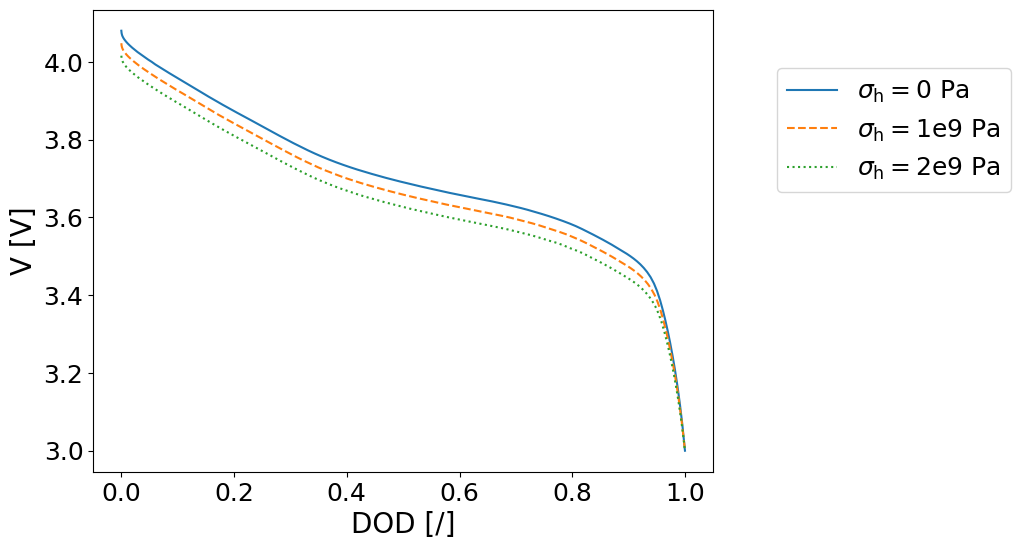

In [87]:
Q_discharged = sol_DFN["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD = (Q_discharged / Q_max)

Q_discharged = sol_DFN_1["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD_1 = (Q_discharged / Q_max)

Q_discharged = sol_DFN_2["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD_2 = (Q_discharged / Q_max)

x_val = [DOD, 
         DOD_1,
        DOD_2
         ]
y_val = [sol_DFN["Voltage [V]"].data, 
         sol_DFN_1["Voltage [V]"].data,
        sol_DFN_2["Voltage [V]"].data
         ]

plt.figure(figsize=fig_size)
for i in range(len(x_val)):
    plt.plot(x_val[i], y_val[i], label=["$\sigma_{\mathrm{h}}=$0 Pa", 
                                        "$\sigma_{\mathrm{h}}=$1e9 Pa", 
                                        "$\sigma_{\mathrm{h}}=$2e9 Pa", 
                                        # "$\sigma_{\mathrm{h}}=$1e9 Pa" , 
                                        # "$\sigma_{\mathrm{h}}=$2e9 Pa", 
                                        # "$\sigma_{\mathrm{h}}=$4e9 Pa", 
                                        # "$\sigma_{\mathrm{h}}=$6e9 Pa",
                                        # "$\sigma_{\mathrm{h}}=$8e9 Pa", 
                                        # "$\sigma_{\mathrm{h}}=$1e10 Pa", 
                                        # # "$\sigma_{\mathrm{h}}=$1e11 Pa"
                                        ][i], 
                                        linestyle=["-", "--", ":", "-", "-", "-", "-", "-", "-", "-"][i])
    
# plt.xlim(3000, 3600)
# plt.ylim(3.5, 3.6)
plt.xlabel("DOD [/]")
plt.ylabel("V [V]")
plt.legend(loc="upper right", bbox_to_anchor=(1.5, 0.9))

if save_fig:
    plt.savefig("graphs/OCV_i0.eps", format='eps', dpi=600, bbox_inches='tight')


## EIS

In [75]:
import numpy as np
from scipy import interpolate
from scipy import optimize
import pybamm
import matplotlib.pyplot as plt

$\sigma_h$ = 0e9 Pa

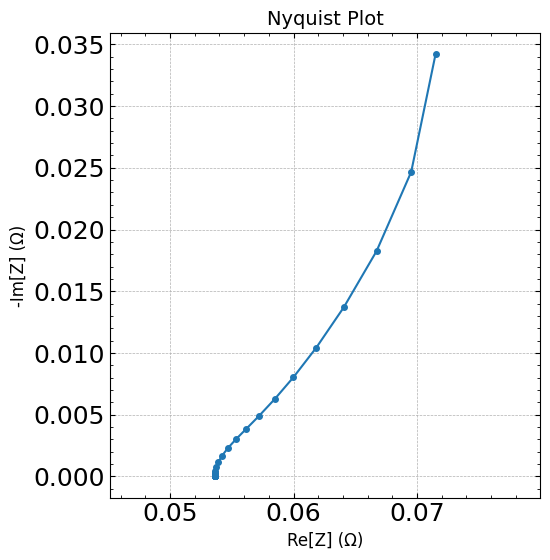

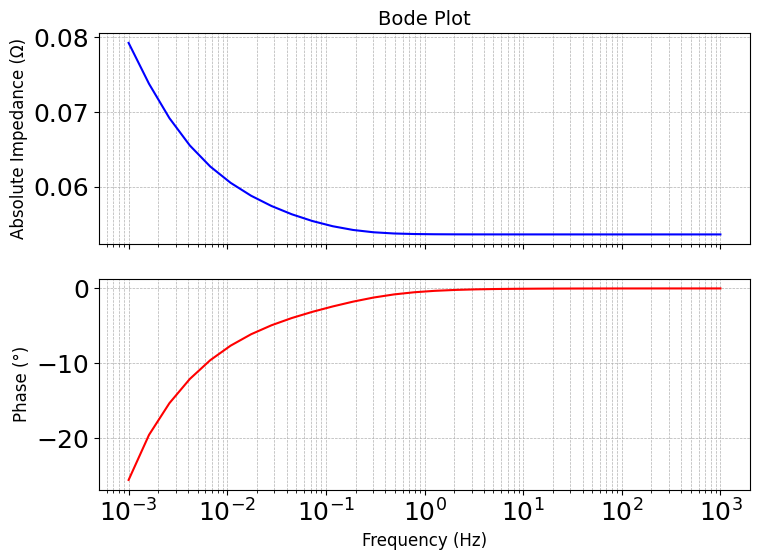

In [79]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.001
high_frequency = 1000
Number_of_Nyquist_points = 30

#initialisation of table where impedances will be stored
Z_0 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    param0 = pybamm.ParameterValues("Ai2020") 
    param0.update(
        {"Hydrostatic stress [Pa]": 0},
        check_already_exists=False  
    )
    param0["Current function [A]"] = my_fun(I_0, freq)

    param1 = pybamm.ParameterValues("Ai2020") 
    param1.update(
        {"Hydrostatic stress [Pa]": 1e9},
        check_already_exists=False  
    )
    param1["Current function [A]"] = my_fun(I_0, freq)

    param2 = pybamm.ParameterValues("Ai2020") 
    param2.update(
        {"Hydrostatic stress [Pa]": 2e9},
        check_already_exists=False  
    )
    param2["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  



    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param0, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )
    # sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param1, var_pts=var_pts, solver=solver, #experiment=experiment 
    #                             )
    # sim_DFN_2 = pybamm.Simulation(model= model, parameter_values=param2, var_pts=var_pts, solver=solver,#experiment=experiment 
    #                             )

    ######################
    # t_eval = [0, 3600]
    # t_eval = np.linspace(0, 0.3, 1000)  # 1 hour simulation with 100 time points
    ######################

    # start = time.time()
    sol_DFN = sim_DFN_0.solve(t_eval=t)
    # end = time.time()
    # print(f"Simulacija DFN_0 zaključena v {end - start:.2f} s.")

    # start = time.time()
    # sol_DFN_1 = sim_DFN_1.solve(t_eval=t)
    # end = time.time()
    # print(f"Simulacija DFN_1 zaključena v {end - start:.2f} s.")

    # start = time.time()
    # sol_DFN_2 = sim_DFN_2.solve(t_eval=t)
    # end = time.time()
    # print(f"Simulacija DFN_2 zaključena v {end - start:.2f} s.")

    # param["Current function [A]"] = my_fun(I_0, freq) #TOLE VRSTICO JE TREBA NUJNO IMET, KI DEFINIRA PARAMETER TOKA, KI JE ZDAJ SINUSNA FUNKCIJA

    # sim = pybamm.Simulation(model, parameter_values=param)
    # solution = sim.solve(t_eval=t)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_0.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_0 = np.array(Z_0)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_0[:, 1], -Z_0[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)', fontsize=12)
plt.ylabel('-Im[Z] (Ω)', fontsize=12)
plt.title('Nyquist Plot', fontsize=14)

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_0[:, 1] + 1j * Z_0[:, 2])  # Combine real and imag parts
phase = np.angle(Z_0[:, 1] + 1j * Z_0[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_0[:, 0]  # Assuming first column is frequency

# Create figure with two subplots
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# Magnitude plot
ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
ax[0].set_title('Bode Plot', fontsize=14)

# Phase plot
ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
ax[1].set_ylabel('Phase (°)', fontsize=12)
ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

$\sigma_h$ = 1e9 Pa

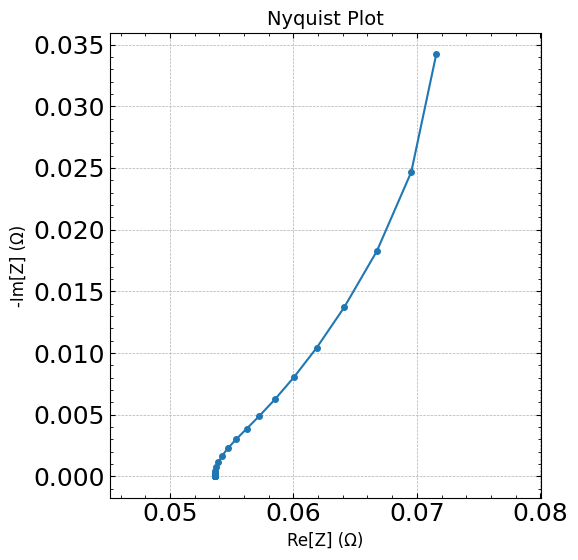

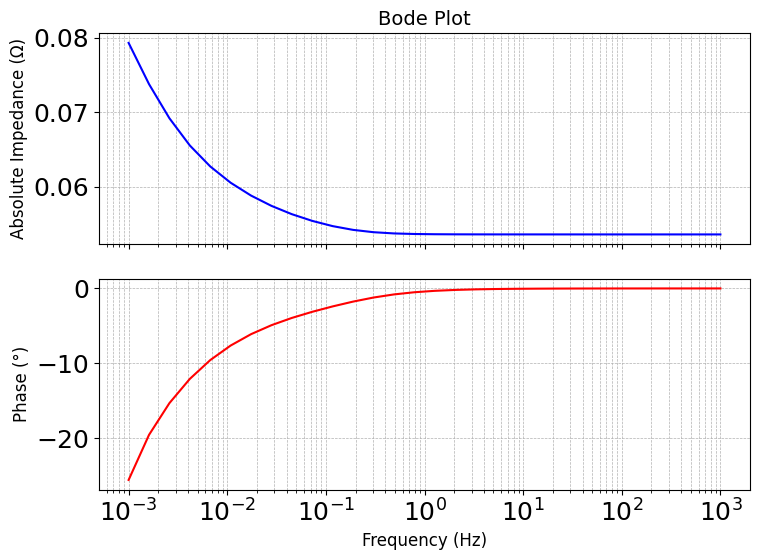

In [80]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.001
high_frequency = 1000
Number_of_Nyquist_points = 30

#initialisation of table where impedances will be stored
Z_1 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    param0 = pybamm.ParameterValues("Ai2020") 
    param0.update(
        {"Hydrostatic stress [Pa]": 0},
        check_already_exists=False  
    )
    param0["Current function [A]"] = my_fun(I_0, freq)

    param1 = pybamm.ParameterValues("Ai2020") 
    param1.update(
        {"Hydrostatic stress [Pa]": 1e9},
        check_already_exists=False  
    )
    param1["Current function [A]"] = my_fun(I_0, freq)

    param2 = pybamm.ParameterValues("Ai2020") 
    param2.update(
        {"Hydrostatic stress [Pa]": 2e9},
        check_already_exists=False  
    )
    param2["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  



    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param1, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )
    # sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param1, var_pts=var_pts, solver=solver, #experiment=experiment 
    #                             )
    # sim_DFN_2 = pybamm.Simulation(model= model, parameter_values=param2, var_pts=var_pts, solver=solver,#experiment=experiment 
    #                             )

    ######################
    # t_eval = [0, 3600]
    # t_eval = np.linspace(0, 0.3, 1000)  # 1 hour simulation with 100 time points
    ######################

    # start = time.time()
    sol_DFN = sim_DFN_0.solve(t_eval=t)
    # end = time.time()
    # print(f"Simulacija DFN_0 zaključena v {end - start:.2f} s.")

    # start = time.time()
    # sol_DFN_1 = sim_DFN_1.solve(t_eval=t)
    # end = time.time()
    # print(f"Simulacija DFN_1 zaključena v {end - start:.2f} s.")

    # start = time.time()
    # sol_DFN_2 = sim_DFN_2.solve(t_eval=t)
    # end = time.time()
    # print(f"Simulacija DFN_2 zaključena v {end - start:.2f} s.")

    # param["Current function [A]"] = my_fun(I_0, freq) #TOLE VRSTICO JE TREBA NUJNO IMET, KI DEFINIRA PARAMETER TOKA, KI JE ZDAJ SINUSNA FUNKCIJA

    # sim = pybamm.Simulation(model, parameter_values=param)
    # solution = sim.solve(t_eval=t)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_1.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_1 = np.array(Z_1)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_1[:, 1], -Z_1[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)', fontsize=12)
plt.ylabel('-Im[Z] (Ω)', fontsize=12)
plt.title('Nyquist Plot', fontsize=14)

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_1[:, 1] + 1j * Z_1[:, 2])  # Combine real and imag parts
phase = np.angle(Z_1[:, 1] + 1j * Z_1[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_1[:, 0]  # Assuming first column is frequency

# Create figure with two subplots
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# Magnitude plot
ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
ax[0].set_title('Bode Plot', fontsize=14)

# Phase plot
ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
ax[1].set_ylabel('Phase (°)', fontsize=12)
ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

$\sigma_h$ = 2e9 Pa

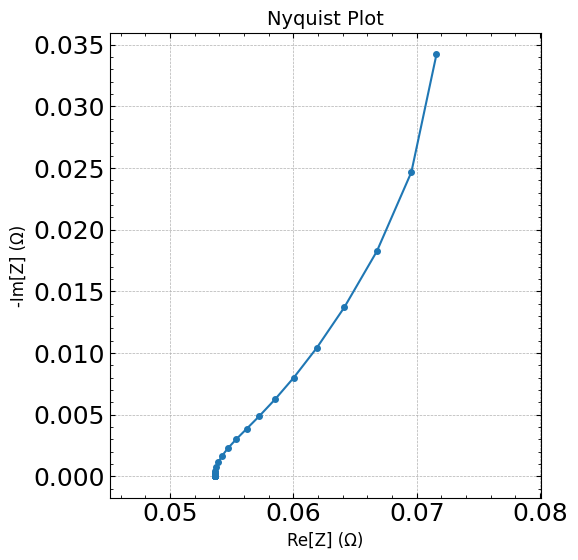

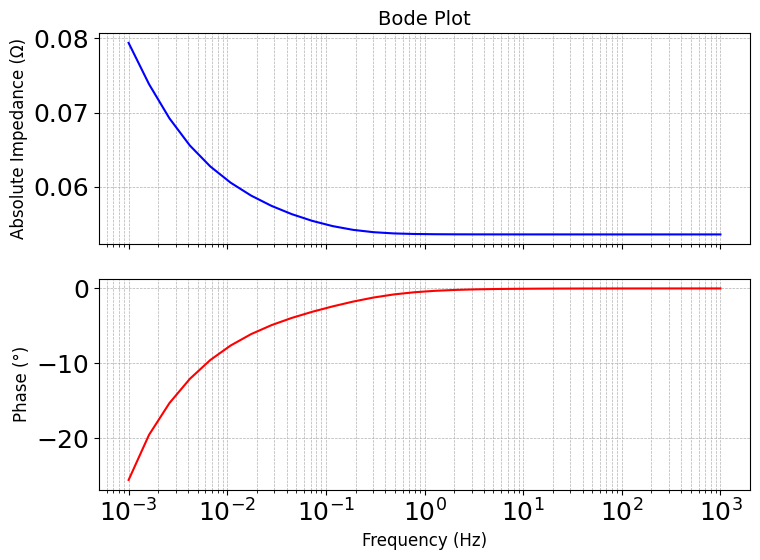

In [78]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.001
high_frequency = 1000
Number_of_Nyquist_points = 30

#initialisation of table where impedances will be stored
Z_2 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    param0 = pybamm.ParameterValues("Ai2020") 
    param0.update(
        {"Hydrostatic stress [Pa]": 0},
        check_already_exists=False  
    )
    param0["Current function [A]"] = my_fun(I_0, freq)

    param1 = pybamm.ParameterValues("Ai2020") 
    param1.update(
        {"Hydrostatic stress [Pa]": 1e9},
        check_already_exists=False  
    )
    param1["Current function [A]"] = my_fun(I_0, freq)

    param2 = pybamm.ParameterValues("Ai2020") 
    param2.update(
        {"Hydrostatic stress [Pa]": 2e9},
        check_already_exists=False  
    )
    param2["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  



    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param2, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )
    # sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param1, var_pts=var_pts, solver=solver, #experiment=experiment 
    #                             )
    # sim_DFN_2 = pybamm.Simulation(model= model, parameter_values=param2, var_pts=var_pts, solver=solver,#experiment=experiment 
    #                             )

    ######################
    # t_eval = [0, 3600]
    # t_eval = np.linspace(0, 0.3, 1000)  # 1 hour simulation with 100 time points
    ######################

    # start = time.time()
    sol_DFN = sim_DFN_0.solve(t_eval=t)
    # end = time.time()
    # print(f"Simulacija DFN_0 zaključena v {end - start:.2f} s.")

    # start = time.time()
    # sol_DFN_1 = sim_DFN_1.solve(t_eval=t)
    # end = time.time()
    # print(f"Simulacija DFN_1 zaključena v {end - start:.2f} s.")

    # start = time.time()
    # sol_DFN_2 = sim_DFN_2.solve(t_eval=t)
    # end = time.time()
    # print(f"Simulacija DFN_2 zaključena v {end - start:.2f} s.")

    # param["Current function [A]"] = my_fun(I_0, freq) #TOLE VRSTICO JE TREBA NUJNO IMET, KI DEFINIRA PARAMETER TOKA, KI JE ZDAJ SINUSNA FUNKCIJA

    # sim = pybamm.Simulation(model, parameter_values=param)
    # solution = sim.solve(t_eval=t)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_2.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_2 = np.array(Z_2)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_2[:, 1], -Z_2[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)', fontsize=12)
plt.ylabel('-Im[Z] (Ω)', fontsize=12)
plt.title('Nyquist Plot', fontsize=14)

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_2[:, 1] + 1j * Z_2[:, 2])  # Combine real and imag parts
phase = np.angle(Z_2[:, 1] + 1j * Z_2[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_2[:, 0]  # Assuming first column is frequency

# Create figure with two subplots
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# Magnitude plot
ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
ax[0].set_title('Bode Plot', fontsize=14)

# Phase plot
ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
ax[1].set_ylabel('Phase (°)', fontsize=12)
ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

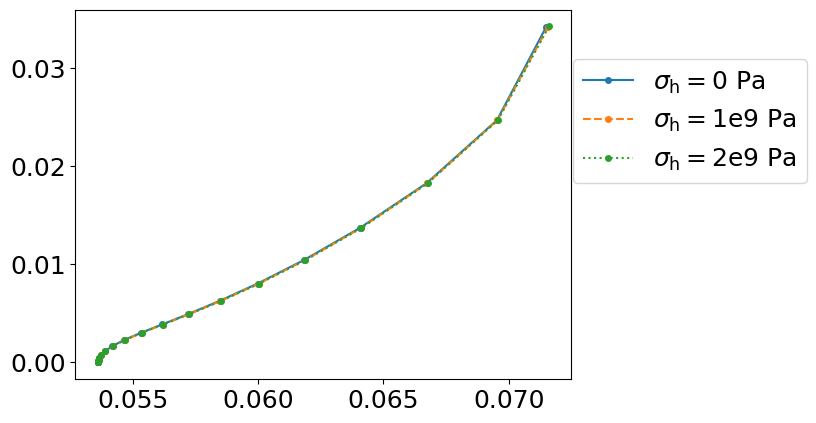

In [85]:
plt.plot(Z_0[:, 1], -Z_0[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=0$ Pa")
plt.plot(Z_1[:, 1], -Z_1[:, 2], marker='o', linestyle='--', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=1$e9 Pa")
plt.plot(Z_2[:, 1], -Z_2[:, 2], marker='o', linestyle=':', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=2$e9 Pa")

plt.legend(loc = "upper right", bbox_to_anchor=(1.5, 0.9))